# 01 - Data Overview and Quality

This notebook performs foundational data checks:
1. Schema and data dictionary alignment
2. Missingness and duplicates
3. Basic distributions and outlier indicators

The goal is to establish trust in the data before modeling.

In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

DATASET_DIR = Path('../dataset')
PLOTS_DIR = Path('../plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

In [12]:
train = pd.read_csv(DATASET_DIR / 'train.csv')
test = pd.read_csv(DATASET_DIR / 'test.csv')
meta = pd.read_csv(DATASET_DIR / 'metaData.csv')

print('train shape:', train.shape)
print('test shape:', test.shape)
print('metadata rows:', meta.shape[0])
display(train.head(3))
display(meta.head(8))

train shape: (221, 37)
test shape: (95, 35)
metadata rows: 37


,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,relative_growth_0_5h,radial_growth_m,radial_growth_rate_m_per_h,centroid_displacement_m,centroid_speed_m_per_h,spread_bearing_deg,spread_bearing_sin,spread_bearing_cos,dist_min_ci_0_5h,dist_std_ci_0_5h,dist_change_ci_0_5h,dist_slope_ci_0_5h,closing_speed_m_per_h,closing_speed_abs_m_per_h,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,0.03545,0.036086,9.007182,2.11179,8.274971,1.940119,70.130507,0.940469,0.339879,6166.121596,0.205085,0.435052,1.090997e-01,-0.102001,0.102001,-0.435052,7.275611e-02,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,2930.925956,0.000000,0.000000,-3.887003e-13,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,3272.375090,0.000000,0.000000,-1.390327e-13,0.000000,0.000000,0.000000,7.965118e-14,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1


,column,type,category,description,units,range
0,event_id,identifier,identifier,Anonymized fire event identifier (stable rando...,NaN,NaN
1,time_to_hit_hours,target,target,Time from t0+5h until fire comes within 5km of...,hours,"[0, 72]"
2,event,target,target,"Event indicator: 1 if fire hit within 72h, 0 i...",NaN,NaN
3,num_perimeters_0_5h,feature,temporal_coverage,Number of perimeters within first 5 hours,NaN,NaN
4,dt_first_last_0_5h,feature,temporal_coverage,Time span between first and last perimeter (ho...,NaN,NaN
5,low_temporal_resolution_0_5h,feature,temporal_coverage,"Flag: 1 if dt < 0.5h or only 1 perimeter, else 0",NaN,NaN
6,area_first_ha,feature,growth,Initial fire area at t0 (hectares),NaN,NaN
7,area_growth_abs_0_5h,feature,growth,Feature from growth category,NaN,NaN


## Data Quality Checks

In [13]:
quality = pd.DataFrame({
    'column': train.columns,
    'dtype': train.dtypes.astype(str).values,
    'missing_train': train.isna().sum().values,
    'missing_test': test.reindex(columns=train.columns.drop(['time_to_hit_hours', 'event'], errors='ignore')).isna().sum().reindex(train.columns, fill_value=np.nan).values
})
display(quality)

print('duplicate train event_id:', train['event_id'].duplicated().sum())
print('duplicate test event_id:', test['event_id'].duplicated().sum())

,column,dtype,missing_train,missing_test
0,event_id,int64,0,0.0
1,num_perimeters_0_5h,int64,0,0.0
2,dt_first_last_0_5h,float64,0,0.0
3,low_temporal_resolution_0_5h,int64,0,0.0
4,area_first_ha,float64,0,0.0
5,area_growth_abs_0_5h,float64,0,0.0
6,area_growth_rel_0_5h,float64,0,0.0
7,area_growth_rate_ha_per_h,float64,0,0.0
8,log1p_area_first,float64,0,0.0
9,log1p_growth,float64,0,0.0


duplicate train event_id: 0
duplicate test event_id: 0


In [14]:
num_cols = train.select_dtypes(include=[np.number]).columns.tolist()
summary = train[num_cols].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]).T
display(summary.head(20))

constant_cols = [c for c in num_cols if train[c].nunique(dropna=False) <= 1]
print('constant columns:', constant_cols)

,count,mean,std,min,1%,5%,50%,95%,99%,max
event_id,221.0,5.384397e+07,2.507456e+07,1.089246e+07,1.196489e+07,1.687087e+07,5.244094e+07,9.340858e+07,9.771708e+07,9.933973e+07
num_perimeters_0_5h,221.0,2.063348e+00,2.578859e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,7.000000e+00,1.200000e+01,1.700000e+01
dt_first_last_0_5h,221.0,9.798688e-01,1.738052e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.797640e+00,4.971844e+00,4.994457e+00
low_temporal_resolution_0_5h,221.0,7.285068e-01,4.457395e-01,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
area_first_ha,221.0,6.191316e+02,1.447724e+03,3.752484e-02,2.909971e-01,2.011464e+00,1.101493e+02,2.300009e+03,7.913480e+03,1.194239e+04
area_growth_abs_0_5h,221.0,2.633240e+01,1.874370e+02,-2.156175e-05,0.000000e+00,0.000000e+00,0.000000e+00,3.532125e+01,5.622635e+02,2.508041e+03
area_growth_rel_0_5h,221.0,1.789087e-01,1.302001e+00,-1.437844e-07,0.000000e+00,0.000000e+00,0.000000e+00,4.833503e-01,3.290252e+00,1.788970e+01
area_growth_rate_ha_per_h,221.0,6.167128e+00,4.046737e+01,-5.292846e-06,0.000000e+00,0.000000e+00,0.000000e+00,1.078449e+01,1.596331e+02,5.204430e+02
log1p_area_first,221.0,4.683276e+00,2.083529e+00,3.683791e-02,2.551875e-01,1.102426e+00,4.710874e+00,7.741103e+00,8.975375e+00,9.387933e+00
log1p_growth,221.0,3.893465e-01,1.340348e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.592403e+00,6.333471e+00,7.827656e+00


constant columns: []


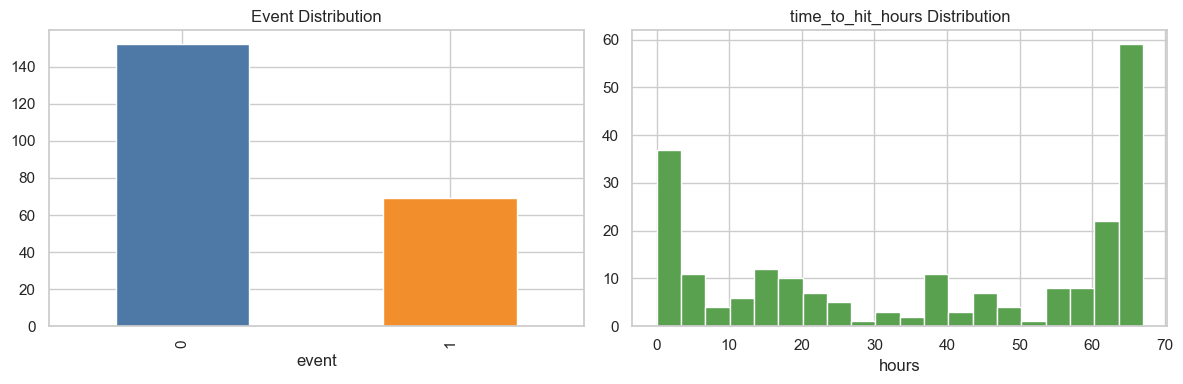

In [15]:
target_cols = ['time_to_hit_hours', 'event']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train['event'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color=['#4E79A7', '#F28E2B'])
axes[0].set_title('Event Distribution')
axes[0].set_xlabel('event')

train['time_to_hit_hours'].hist(ax=axes[1], bins=20, color='#59A14F')
axes[1].set_title('time_to_hit_hours Distribution')
axes[1].set_xlabel('hours')

plt.tight_layout()
plt.savefig(PLOTS_DIR / '01_target_distributions.png', dpi=150)
plt.show()